# Heart Disease Diagnosis — Colab Experiment Lab

Notebook dựng lại pipeline của project theo hướng leakage-safe và **không dùng Optuna**.

Flow: Cleveland data → binary target → train/test → imputation → MinMaxScaler + OneHotEncoder → Mutual Information 80% → model comparison → soft-voting ensemble → thử dữ liệu và quan sát kết quả. Notebook này không xuất model.

> Educational/research use only. Kết quả không phải chẩn đoán y khoa.

In [1]:
!pip install -q gdown scikit-learn pandas numpy matplotlib seaborn imbalanced-learn xgboost lightgbm


In [2]:
import sys
import pickle
import time
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier,
)
from sklearn.feature_selection import SelectPercentile, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold, cross_validate, train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
print('Python:', sys.version.split()[0])
print('scikit-learn:', sklearn.__version__)


Python: 3.12.13
scikit-learn: 1.6.1


## 1. Tải và kiểm tra Cleveland dataset

In [3]:
FILE_ID = '1YTzUy_RreXqnM5fqMR0hOLZPeXOvYoju'
DATA_PATH = Path('/content/cleveland.csv')
gdown.download(id=FILE_ID, output=str(DATA_PATH), quiet=False)

FEATURES = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal',
]
NUMERICAL_FEATURES = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORICAL_FEATURES = [
    'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal',
]

df = pd.read_csv(
    DATA_PATH, header=None, names=FEATURES + ['target_original'],
    na_values=['?'],
)
df['target'] = (df['target_original'] > 0).astype(int)

assert df.shape[0] == 303
assert df[FEATURES].shape[1] == 13
assert df['target'].isin([0, 1]).all()

eda_summary = {
    'rows': len(df),
    'features': len(FEATURES),
    'duplicates': int(df[FEATURES + ['target_original']].duplicated().sum()),
    'missing_values': int(df[FEATURES].isna().sum().sum()),
    'healthy': int((df['target'] == 0).sum()),
    'disease': int((df['target'] == 1).sum()),
    'positive_rate': float(df['target'].mean()),
}
display(pd.Series(eda_summary, name='EDA summary'))
display(df.head())


Downloading...
From: https://drive.google.com/uc?id=1YTzUy_RreXqnM5fqMR0hOLZPeXOvYoju
To: /content/cleveland.csv
100%|██████████| 11.2k/11.2k [00:00<00:00, 21.8MB/s]


,EDA summary
rows,303.000000
features,13.000000
duplicates,0.000000
missing_values,6.000000
healthy,164.000000
disease,139.000000
positive_rate,0.458746


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target_original,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0


## 2. Chia train/test

Model selection chỉ dùng repeated CV trên train. Test được dùng một lần sau khi chốt cấu hình.

In [4]:
X = df[FEATURES].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y,
)

split_summary = pd.DataFrame([
    {
        'split': 'train', 'rows': len(X_train),
        'positive_rate': y_train.mean(),
        'missing': X_train.isna().sum().sum(),
    },
    {
        'split': 'test', 'rows': len(X_test),
        'positive_rate': y_test.mean(),
        'missing': X_test.isna().sum().sum(),
    },
])
display(split_summary.round(4))


,split,rows,positive_rate,missing
0,train,242,0.4587,2
1,test,61,0.4590,4


## 3. Preprocessing + Mutual Information

Cấu hình đã được các notebook trước chọn: Basic FE, MinMaxScaler và SelectPercentile Mutual Information 80%. Mọi bước học từ dữ liệu đều nằm trong sklearn Pipeline nên được fit riêng trong từng CV fold.

In [5]:
def mutual_info_fixed(X, y):
    return mutual_info_classif(X, y, random_state=RANDOM_STATE)

def make_preprocessor():
    numeric = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler()),
    ])
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric, NUMERICAL_FEATURES),
        ('cat', categorical, CATEGORICAL_FEATURES),
    ])

def make_pipeline(classifier):
    return Pipeline([
        ('preprocessor', make_preprocessor()),
        ('feature_selection', SelectPercentile(
            score_func=mutual_info_fixed, percentile=80,
        )),
        ('classifier', clone(classifier)),
    ])


## 4. So sánh model không tuning

In [6]:
MODELS = {
    'lr': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'dt': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'rf': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'ada': AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'gb': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'svm': SVC(probability=True, random_state=RANDOM_STATE),
}
MODEL_NAMES = {
    'lr': 'Logistic Regression', 'knn': 'K-Nearest Neighbors',
    'dt': 'Decision Tree', 'rf': 'Random Forest',
    'ada': 'AdaBoost', 'gb': 'Gradient Boosting', 'svm': 'SVM',
}

cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=10, random_state=RANDOM_STATE,
)
scoring = {
    'accuracy': 'accuracy', 'precision': 'precision',
    'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc',
}

records = []
pipelines = {}
raw_cv = {}
for key, classifier in MODELS.items():
    print('Evaluating:', MODEL_NAMES[key])
    pipeline = make_pipeline(classifier)
    pipelines[key] = pipeline
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        n_jobs=-1, return_train_score=True,
    )
    raw_cv[key] = scores
    records.append({
        'key': key, 'model': MODEL_NAMES[key],
        'train_accuracy_mean': scores['train_accuracy'].mean(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'precision_mean': scores['test_precision'].mean(),
        'recall_mean': scores['test_recall'].mean(),
        'recall_std': scores['test_recall'].std(),
        'f1_mean': scores['test_f1'].mean(),
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'roc_auc_std': scores['test_roc_auc'].std(),
    })

cv_results = pd.DataFrame(records)
cv_results['overfit_gap'] = (
    cv_results['train_accuracy_mean'] - cv_results['accuracy_mean']
)
cv_results = cv_results.sort_values(
    ['roc_auc_mean', 'recall_mean', 'f1_mean'], ascending=False,
).reset_index(drop=True)
display(cv_results.round(4))


Evaluating: Logistic Regression
Evaluating: K-Nearest Neighbors
Evaluating: Decision Tree
Evaluating: Random Forest
Evaluating: AdaBoost
Evaluating: Gradient Boosting
Evaluating: SVM


,key,model,train_accuracy_mean,accuracy_mean,accuracy_std,precision_mean,recall_mean,recall_std,f1_mean,roc_auc_mean,roc_auc_std,overfit_gap
0,lr,Logistic Regression,0.8646,0.8293,0.0451,0.8311,0.7969,0.0810,0.8098,0.9018,0.0351,0.0353
1,svm,SVM,0.9020,0.8091,0.0432,0.8138,0.7671,0.0806,0.7856,0.9008,0.0374,0.0929
2,rf,Random Forest,1.0000,0.8046,0.0428,0.8088,0.7609,0.0807,0.7802,0.8955,0.0344,0.1954
3,ada,AdaBoost,0.8952,0.8046,0.0510,0.8099,0.7583,0.0837,0.7797,0.8685,0.0450,0.0906
4,knn,K-Nearest Neighbors,0.8587,0.8021,0.0437,0.8069,0.7583,0.0817,0.7775,0.8612,0.0426,0.0566
5,gb,Gradient Boosting,0.9971,0.7760,0.0502,0.7629,0.7517,0.0921,0.7533,0.8552,0.0409,0.2211
6,dt,Decision Tree,1.0000,0.7303,0.0478,0.7100,0.7068,0.0894,0.7047,0.7283,0.0484,0.2697


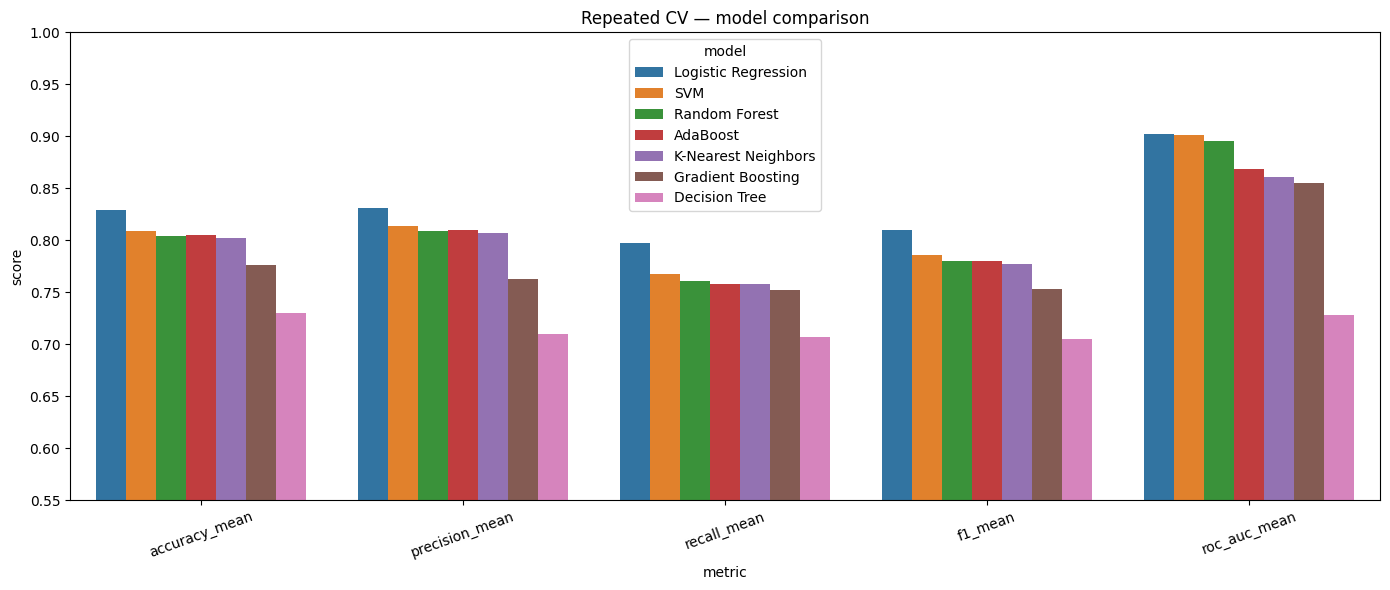

In [7]:
plot_data = cv_results.melt(
    id_vars=['model'],
    value_vars=['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean'],
    var_name='metric', value_name='score',
)
plt.figure(figsize=(14, 6))
sns.barplot(data=plot_data, x='metric', y='score', hue='model')
plt.ylim(0.55, 1.0)
plt.title('Repeated CV — model comparison')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Fit từng model, tạo ensemble và đánh giá test

Ba model đứng đầu theo CV ROC AUC được dùng cho soft voting. Preprocessor và selector chỉ fit trên train.

In [8]:
# Fit shared preprocessing/selection để so sánh model và thử dữ liệu.
final_preprocessor = make_preprocessor()
X_train_pre = final_preprocessor.fit_transform(X_train)
X_test_pre = final_preprocessor.transform(X_test)

final_selector = SelectPercentile(
    score_func=mutual_info_fixed, percentile=80,
)
X_train_selected = final_selector.fit_transform(X_train_pre, y_train)
X_test_selected = final_selector.transform(X_test_pre)
fs_indices = np.where(final_selector.get_support())[0]
all_feature_names = final_preprocessor.get_feature_names_out()
selected_feature_names = all_feature_names[fs_indices].tolist()

print('After preprocessing:', X_train_pre.shape[1])
print('After selection:', X_train_selected.shape[1])
print('Selected features:', selected_feature_names)

fitted_models = {}
test_records = []
test_predictions = {}
for key, classifier in MODELS.items():
    model = clone(classifier).fit(X_train_selected, y_train)
    fitted_models[key] = model
    pred = model.predict(X_test_selected)
    prob = model.predict_proba(X_test_selected)[:, 1]
    test_predictions[key] = {'pred': pred, 'prob': prob}
    test_records.append({
        'key': key, 'model': MODEL_NAMES[key],
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, prob),
    })

top_keys = cv_results.head(3)['key'].tolist()
ensemble = VotingClassifier(
    estimators=[(key, clone(MODELS[key])) for key in top_keys],
    voting='soft', n_jobs=-1,
).fit(X_train_selected, y_train)
ensemble_pred = ensemble.predict(X_test_selected)
ensemble_prob = ensemble.predict_proba(X_test_selected)[:, 1]
fitted_models['ensemble'] = ensemble
MODEL_NAMES['ensemble'] = 'Ensemble'
test_predictions['ensemble'] = {'pred': ensemble_pred, 'prob': ensemble_prob}
test_records.append({
    'key': 'ensemble', 'model': 'Ensemble',
    'accuracy': accuracy_score(y_test, ensemble_pred),
    'precision': precision_score(y_test, ensemble_pred, zero_division=0),
    'recall': recall_score(y_test, ensemble_pred, zero_division=0),
    'f1': f1_score(y_test, ensemble_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, ensemble_prob),
})

test_results = pd.DataFrame(test_records).sort_values(
    ['roc_auc', 'recall', 'f1'], ascending=False,
).reset_index(drop=True)
print('Ensemble members:', [MODEL_NAMES[key] for key in top_keys])
display(test_results.round(4))


After preprocessing: 28
After selection: 22
Selected features: ['num__trestbps', 'num__chol', 'num__thalach', 'num__oldpeak', 'cat__sex_0.0', 'cat__sex_1.0', 'cat__cp_1.0', 'cat__cp_2.0', 'cat__cp_3.0', 'cat__cp_4.0', 'cat__fbs_1.0', 'cat__restecg_0.0', 'cat__restecg_1.0', 'cat__exang_0.0', 'cat__exang_1.0', 'cat__slope_2.0', 'cat__slope_3.0', 'cat__ca_0.0', 'cat__ca_1.0', 'cat__ca_3.0', 'cat__thal_3.0', 'cat__thal_7.0']
Ensemble members: ['Logistic Regression', 'SVM', 'Random Forest']


,key,model,accuracy,precision,recall,f1,roc_auc
0,ada,AdaBoost,0.8689,0.8125,0.9286,0.8667,0.9665
1,lr,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9545
2,ensemble,Ensemble,0.8525,0.8065,0.8929,0.8475,0.9502
3,svm,SVM,0.8525,0.8276,0.8571,0.8421,0.9459
4,rf,Random Forest,0.8852,0.8387,0.9286,0.8814,0.9394
5,knn,K-Nearest Neighbors,0.8525,0.8065,0.8929,0.8475,0.9356
6,gb,Gradient Boosting,0.8852,0.8387,0.9286,0.8814,0.9351
7,dt,Decision Tree,0.7377,0.6765,0.8214,0.7419,0.7440


Best test result: Logistic Regression
              precision    recall  f1-score   support

  No disease     0.9310    0.8182    0.8710        33
     Disease     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61

Confusion matrix:
 [[27  6]
 [ 2 26]]


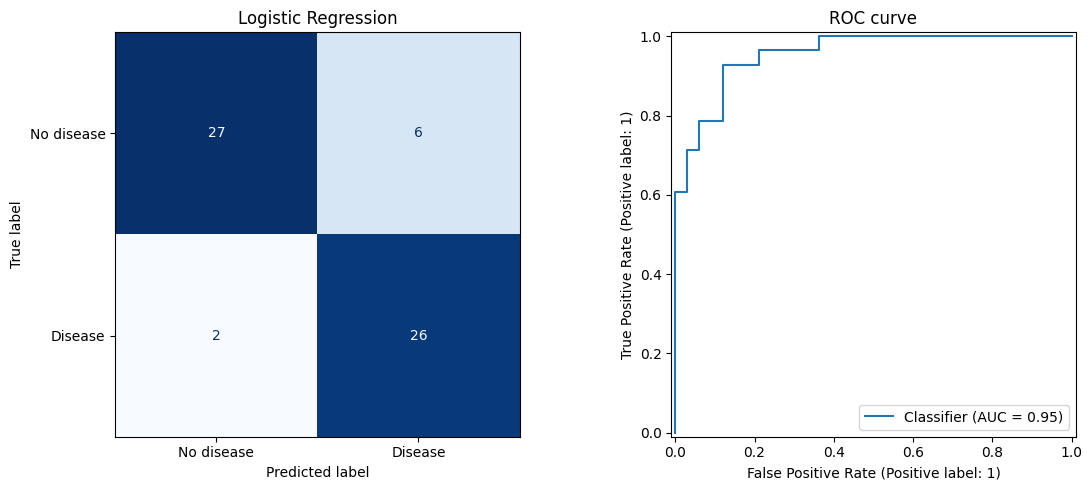

In [9]:
# Model để báo cáo được chọn từ CV, không chọn theo test.
best_key = cv_results.iloc[0]['key']
best_pred = test_predictions[best_key]['pred']
best_prob = test_predictions[best_key]['prob']

print('Best test result:', MODEL_NAMES[best_key])
print(classification_report(
    y_test, best_pred, target_names=['No disease', 'Disease'], digits=4,
))
print('Confusion matrix:\n', confusion_matrix(y_test, best_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, display_labels=['No disease', 'Disease'],
    cmap='Blues', colorbar=False, ax=axes[0],
)
RocCurveDisplay.from_predictions(y_test, best_prob, ax=axes[1])
axes[0].set_title(MODEL_NAMES[best_key])
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.show()


## 6. Thử dữ liệu mới

Nhập 13 thông số của một bệnh nhân mẫu để quan sát dự đoán từng model và ensemble. Không lưu hoặc xuất model.

In [10]:
patient = pd.DataFrame([{
    'age': 55,
    'sex': 1,
    'cp': 2,
    'trestbps': 130,
    'chol': 250,
    'fbs': 0,
    'restecg': 1,
    'thalach': 150,
    'exang': 0,
    'oldpeak': 2.0,
    'slope': 2,
    'ca': 0,
    'thal': 7,
}])

patient_pre = final_preprocessor.transform(patient)
patient_selected = final_selector.transform(patient_pre)
patient_results = []
for key, model in fitted_models.items():
    prediction = int(model.predict(patient_selected)[0])
    probability = float(model.predict_proba(patient_selected)[0, 1])
    patient_results.append({
        'model': MODEL_NAMES[key],
        'prediction': prediction,
        'risk_label': 'High Risk' if prediction == 1 else 'Low Risk',
        'disease_probability': probability,
    })

display(pd.DataFrame(patient_results).sort_values(
    'disease_probability', ascending=False,
).round(4))


,model,prediction,risk_label,disease_probability
5,Gradient Boosting,1,High Risk,0.8885
0,Logistic Regression,1,High Risk,0.6594
3,Random Forest,1,High Risk,0.5950
7,Ensemble,1,High Risk,0.5848
4,AdaBoost,1,High Risk,0.5289
6,SVM,0,Low Risk,0.5000
1,K-Nearest Neighbors,0,Low Risk,0.4000
2,Decision Tree,0,Low Risk,0.0000


In [11]:
# Thử nhiều dòng dữ liệu: giữ đúng 13 cột FEATURES.
# Có thể thay DataFrame dưới đây bằng pd.read_csv('/content/new_patients.csv').
new_patients = X_test.head(5).copy()
new_pre = final_preprocessor.transform(new_patients)
new_selected = final_selector.transform(new_pre)
new_result = new_patients.copy()
new_result['ensemble_prediction'] = ensemble.predict(new_selected)
new_result['ensemble_probability'] = ensemble.predict_proba(new_selected)[:, 1]
display(new_result)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,ensemble_prediction,ensemble_probability
219,59,1,4,138,271,0,2,182,0,0.0,1,0.0,3.0,0,0.185558
271,66,1,4,160,228,0,2,138,0,2.3,1,0.0,6.0,1,0.580850
89,51,0,3,130,256,0,2,149,0,0.5,1,0.0,3.0,0,0.032575
101,34,1,1,118,182,0,2,174,0,0.0,1,0.0,3.0,0,0.096318
67,54,1,3,150,232,0,2,165,0,1.6,1,0.0,7.0,0,0.359196


## 7. Nghiên cứu tăng cường dữ liệu

So sánh `none`, RandomOverSampler và SMOTENC. Augmentation chỉ chạy trong fold train. Cleveland gần cân bằng (164/139), vì vậy augmentation phải chứng minh được lợi ích thay vì được bật mặc định.

In [ ]:
# Impute trước SMOTENC; encode/scale sau augmentation.
pre_impute = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUMERICAL_FEATURES),
    ('cat', SimpleImputer(strategy='most_frequent'), CATEGORICAL_FEATURES),
])
numeric_indices = list(range(len(NUMERICAL_FEATURES)))
categorical_indices = list(range(
    len(NUMERICAL_FEATURES), len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES)
))
postprocess = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_indices),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_indices),
])

augmentation_options = {
    'none': 'passthrough',
    'random_over': RandomOverSampler(random_state=RANDOM_STATE),
    'smotenc': SMOTENC(
        categorical_features=categorical_indices,
        random_state=RANDOM_STATE,
        k_neighbors=5,
    ),
}
research_models = {
    'logreg': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'svm_rbf': SVC(probability=True, random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1,
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1,
    ),
    'hist_gb': HistGradientBoostingClassifier(
        max_iter=100, l2_regularization=1.0, random_state=RANDOM_STATE,
    ),
    'xgboost': XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=1,
    ),
    'lightgbm': LGBMClassifier(
        n_estimators=150, num_leaves=15, max_depth=4, learning_rate=0.05,
        verbosity=-1, random_state=RANDOM_STATE, n_jobs=1,
    ),
}


In [ ]:
augmentation_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=5, random_state=RANDOM_STATE,
)
augmentation_records = []
for augmentation_name, augmentation in augmentation_options.items():
    for model_name, classifier in research_models.items():
        print(f'Evaluating {augmentation_name} + {model_name}')
        experiment = ImbPipeline([
            ('impute', clone(pre_impute)),
            ('augment', clone(augmentation) if augmentation != 'passthrough' else 'passthrough'),
            ('encode_scale', clone(postprocess)),
            ('select', SelectPercentile(
                score_func=mutual_info_fixed, percentile=80,
            )),
            ('model', clone(classifier)),
        ])
        started = time.perf_counter()
        scores = cross_validate(
            experiment, X_train, y_train, cv=augmentation_cv,
            scoring=scoring, n_jobs=1, return_train_score=False,
        )
        cv_seconds = time.perf_counter() - started
        experiment.fit(X_train, y_train)
        size_kb = len(pickle.dumps(experiment)) / 1024
        latency_sample = X_train.iloc[:100]
        started = time.perf_counter()
        for _ in range(20):
            experiment.predict_proba(latency_sample)
        latency_ms = (
            (time.perf_counter() - started) * 1000
            / (20 * len(latency_sample))
        )
        augmentation_records.append({
            'augmentation': augmentation_name,
            'model': model_name,
            'accuracy_mean': scores['test_accuracy'].mean(),
            'accuracy_std': scores['test_accuracy'].std(),
            'precision_mean': scores['test_precision'].mean(),
            'recall_mean': scores['test_recall'].mean(),
            'recall_std': scores['test_recall'].std(),
            'f1_mean': scores['test_f1'].mean(),
            'roc_auc_mean': scores['test_roc_auc'].mean(),
            'roc_auc_std': scores['test_roc_auc'].std(),
            'cv_seconds': cv_seconds,
            'size_kb': size_kb,
            'latency_ms_per_row': latency_ms,
        })

augmentation_results = pd.DataFrame(augmentation_records).sort_values(
    ['roc_auc_mean', 'recall_mean', 'f1_mean'], ascending=False,
).reset_index(drop=True)
display(augmentation_results.round(4))


In [ ]:
# Chỉ xét model gọn dưới 250 KB; ưu tiên AUC rồi Recall/F1.
compact_candidates = augmentation_results[
    augmentation_results['size_kb'] <= 250
].copy()
compact_candidates = compact_candidates.sort_values(
    ['roc_auc_mean', 'recall_mean', 'f1_mean'], ascending=False,
).reset_index(drop=True)
display(compact_candidates.head(10).round(4))

recommended = compact_candidates.iloc[0]
print('EMPIRICAL COMPACT CHAMPION')
print('Model:', recommended['model'])
print('Augmentation:', recommended['augmentation'])
print('ROC AUC:', round(float(recommended['roc_auc_mean']), 4))
print('Recall:', round(float(recommended['recall_mean']), 4))
print('F1:', round(float(recommended['f1_mean']), 4))
print('Size KB:', round(float(recommended['size_kb']), 2))
print('Latency ms/row:', round(float(recommended['latency_ms_per_row']), 4))

augmentation_effect = augmentation_results.pivot(
    index='model', columns='augmentation', values=['roc_auc_mean', 'recall_mean']
)
display(augmentation_effect.round(4))


## OPTIONAL — Modern tabular models (đã bỏ qua)

Benchmark nang dung cung 5 fold. CatBoost nhan categorical features truc tiep; TabPFN va TabM dung preprocessing chi fit tren fold train. Nen bat GPU cho TabPFN/TabM.

In [ ]:
# SKIPPED: khong cai CatBoost/TabPFN/TabM trong flow hien tai.


In [ ]:
"""SKIPPED MODERN MODEL SETUP
import os

# Paste the key between the quotes BEFORE importing tabpfn.
TABPFN_TOKEN = ''
if not TABPFN_TOKEN.strip():
    raise ValueError('Hay dien TabPFN API key vao bien TABPFN_TOKEN')
os.environ['TABPFN_TOKEN'] = TABPFN_TOKEN.strip()
assert os.environ.get('TABPFN_TOKEN'), 'TABPFN_TOKEN chua duoc gan'
print('TABPFN_TOKEN configured:', True)

import torch
import torch.nn.functional as F
from catboost import CatBoostClassifier
from tabm import TabM
from tabpfn import TabPFNClassifier
from sklearn.model_selection import StratifiedKFold

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODERN_FOLDS = 5
TABM_EPOCHS = 250
print('Device:', DEVICE)
"""


In [ ]:
"""SKIPPED MODERN MODEL HELPERS
def metric_record(name, fold, y_true, probability, seconds):
    prediction = (np.asarray(probability) >= 0.5).astype(int)
    return {'model': name, 'fold': fold,
            'accuracy': accuracy_score(y_true, prediction),
            'precision': precision_score(y_true, prediction, zero_division=0),
            'recall': recall_score(y_true, prediction, zero_division=0),
            'f1': f1_score(y_true, prediction, zero_division=0),
            'roc_auc': roc_auc_score(y_true, probability), 'seconds': seconds}

def prepare_catboost_frame(frame, medians=None, modes=None):
    result = frame.copy()
    if medians is None:
        medians = result[NUMERICAL_FEATURES].median()
        modes = result[CATEGORICAL_FEATURES].mode().iloc[0]
    result[NUMERICAL_FEATURES] = result[NUMERICAL_FEATURES].fillna(medians).astype(float)
    for column in CATEGORICAL_FEATURES:
        result[column] = result[column].fillna(modes[column]).astype(int).astype(str)
    return result, medians, modes

def fit_predict_tabm(X_fit, y_fit, X_eval, seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    x_fit = torch.as_tensor(X_fit, dtype=torch.float32, device=DEVICE)
    y_tensor = torch.as_tensor(np.asarray(y_fit), dtype=torch.long, device=DEVICE)
    x_eval = torch.as_tensor(X_eval, dtype=torch.float32, device=DEVICE)
    model = TabM.make(n_num_features=X_fit.shape[1], cat_cardinalities=[], d_out=2,
                      arch_type='tabm-mini', k=16, n_blocks=2, d_block=128).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    model.train()
    for _ in range(TABM_EPOCHS):
        optimizer.zero_grad()
        logits = model(x_fit, None)
        targets = y_tensor[:, None].expand(-1, logits.shape[1])
        loss = F.cross_entropy(logits.flatten(0, 1), targets.flatten())
        loss.backward(); optimizer.step()
    model.eval()
    with torch.inference_mode():
        probability = model(x_eval, None).softmax(-1)[..., 1].mean(1)
    return probability.cpu().numpy()
"""


In [ ]:
"""SKIPPED MODERN MODEL BENCHMARK
modern_cv = StratifiedKFold(n_splits=MODERN_FOLDS, shuffle=True, random_state=RANDOM_STATE)
modern_records = []
for fold, (fit_idx, eval_idx) in enumerate(modern_cv.split(X_train, y_train), 1):
    X_fit, X_eval = X_train.iloc[fit_idx].copy(), X_train.iloc[eval_idx].copy()
    y_fit, y_eval = y_train.iloc[fit_idx].copy(), y_train.iloc[eval_idx].copy()
    fold_preprocessor = make_preprocessor()
    X_fit_matrix = fold_preprocessor.fit_transform(X_fit, y_fit)
    X_eval_matrix = fold_preprocessor.transform(X_eval)
    if hasattr(X_fit_matrix, 'toarray'):
        X_fit_matrix, X_eval_matrix = X_fit_matrix.toarray(), X_eval_matrix.toarray()

    started = time.perf_counter()
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE + fold).fit(X_fit_matrix, y_fit)
    prob = model.predict_proba(X_eval_matrix)[:, 1]
    modern_records.append(metric_record('Logistic Regression', fold, y_eval, prob, time.perf_counter()-started))

    X_fit_cb, medians, modes = prepare_catboost_frame(X_fit)
    X_eval_cb, _, _ = prepare_catboost_frame(X_eval, medians, modes)
    started = time.perf_counter()
    model = CatBoostClassifier(iterations=500, depth=5, learning_rate=0.03,
        loss_function='Logloss', eval_metric='AUC', random_seed=RANDOM_STATE+fold,
        verbose=False, allow_writing_files=False, thread_count=-1)
    model.fit(X_fit_cb, y_fit, cat_features=CATEGORICAL_FEATURES)
    prob = model.predict_proba(X_eval_cb)[:, 1]
    modern_records.append(metric_record('CatBoost native', fold, y_eval, prob, time.perf_counter()-started))

    started = time.perf_counter()
    model = TabPFNClassifier(device=DEVICE).fit(X_fit_matrix, y_fit.to_numpy())
    prob = model.predict_proba(X_eval_matrix)[:, 1]
    modern_records.append(metric_record('TabPFN', fold, y_eval, prob, time.perf_counter()-started))
    del model

    started = time.perf_counter()
    prob = fit_predict_tabm(X_fit_matrix, y_fit, X_eval_matrix, RANDOM_STATE+fold)
    modern_records.append(metric_record('TabM-mini k=16', fold, y_eval, prob, time.perf_counter()-started))
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f'Completed fold {fold}/{MODERN_FOLDS}')

modern_fold_results = pd.DataFrame(modern_records)
modern_results = modern_fold_results.groupby('model').agg(
    accuracy_mean=('accuracy','mean'), accuracy_std=('accuracy','std'),
    precision_mean=('precision','mean'), recall_mean=('recall','mean'),
    recall_std=('recall','std'), recall_min=('recall','min'), f1_mean=('f1','mean'),
    roc_auc_mean=('roc_auc','mean'), roc_auc_std=('roc_auc','std'),
    total_seconds=('seconds','sum')).sort_values(
        ['roc_auc_mean','recall_mean'], ascending=False).reset_index()
display(modern_results.round(4))
"""


In [ ]:
"""SKIPPED MODERN MODEL DECISION
winner = modern_results.iloc[0]
baseline = modern_results[modern_results['model']=='Logistic Regression'].iloc[0]
print('MODERN BENCHMARK WINNER:', winner['model'])
print('ROC AUC:', round(float(winner['roc_auc_mean']), 4))
print('Recall:', round(float(winner['recall_mean']), 4))
print('AUC delta vs LR:', round(float(winner['roc_auc_mean']-baseline['roc_auc_mean']), 4))
print('Also inspect roc_auc_std, recall_min and total_seconds before choosing.')
"""


## 8. Kết thúc phiên thử nghiệm

Notebook dừng ở bước benchmark augmentation, model gọn nhẹ, CatBoost, TabPFN, TabM, ensemble và thử dữ liệu mới. Chỉ thay Logistic Regression khi model hiện đại cải thiện ổn định qua nhiều fold và chi phí tài nguyên chấp nhận được. Đây không phải tuyên bố SOTA lâm sàng hay SOTA toàn cầu. Không tạo `.pkl`, JSON hoặc ZIP.